# Rayong Crop Tracker · End-to-end pipeline

Sentinel-2 L2A → OpenSR super-resolution → LoRA / DiffusionSat augmentation → texture + index features → Random Forest cascade.

Stages map 1:1 to the [tracker board](../README.md). Heavy steps cache to disk so a kernel restart only costs you a few imports.


## 1 · Setup

Use `notebooks/environment.yml` (`conda env create -f notebooks/environment.yml`). If you must pip-install, uncomment the cell below.


In [ ]:
# !pip install -q --upgrade \
#     openeo "openeo-processes-dask[implementations]" pystac-client planetary-computer \
#     rasterio rioxarray xarray geopandas shapely pyproj fiona mgrs \
#     opensr-model omegaconf diffusers transformers accelerate peft safetensors \
#     scikit-image scikit-learn imbalanced-learn \
#     matplotlib seaborn tqdm pyarrow \
#     --extra-index-url https://download.pytorch.org/whl/cu121 "torch==2.3.1+cu121" torchvision torchaudio
# !git clone https://github.com/samar-khanna/DiffusionSat.git ../external/DiffusionSat || true


In [2]:
from __future__ import annotations
import sys, json, math, warnings, datetime as dt
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import rasterio
import rioxarray as rxr
import xarray as xr
import geopandas as gpd

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_context("notebook"); sns.set_style("whitegrid")
print("python:", sys.version.split()[0])


python: 3.12.13


In [3]:
def _repo_root_default() -> Path:
    if "__file__" in globals():
        return Path(__file__).resolve().parents[1]
    here = Path.cwd().resolve()
    for p in (here, *here.parents):
        if (p / "package.json").exists() and (p / "notebooks").exists():
            return p
    return here


@dataclass
class Config:
    repo_root:   Path = field(default_factory=_repo_root_default)
    work_root:   Path = None
    cache_root:  Path = None
    out_root:    Path = None
    ldd_landuse: Path = None
    ldd_admin:   Path = None

    aoi_quadrant: str   = "SE"        # FULL / NW / NE / SW / SE / CUSTOM
    aoi_bbox:     tuple = (101.55, 12.70, 101.65, 12.80)
    aoi_name:     str   = "klaeng_10km"

    time_start: str = "2024-01-01"
    time_end:   str = "2024-12-31"

    # SMOKE TEST: tiny AOI + 2 months + cheap RF so the whole pipeline can
    # run end-to-end in a few minutes. Once you've validated every cell,
    # set smoke_test = False (or override per-CFG) for the full load.
    smoke_test:           bool  = True
    smoke_bbox_deg:       float = 0.025          # half-side around AOI centroid (~2.5 km)
    smoke_months:         int   = 2              # cap time window from time_start
    smoke_rf_estimators:  int   = 200            # vs production rf_n_estimators
    smoke_sr_steps:       int   = 25             # diffusion sampling
    full_sr_steps:        int   = 50

    bands_10m: tuple = ("B02", "B03", "B04", "B08")
    bands_20m: tuple = ("B05", "B06", "B07", "B11", "B12")
    scl_band:  str   = "SCL"

    sr_scale: int = 4
    # Resolved at runtime from smoke_test → smoke_sr_steps / full_sr_steps.
    sr_steps: int = 50

    diffusionsat_repo: Path = None
    minority_classes:  tuple = ("A203", "A302", "A401")
    samples_per_minor: int   = 200

    rf_n_estimators: int  = 600
    rf_max_depth:    int  = None
    cascade:         bool = True
    seed:            int  = 42

    def __post_init__(self):
        data = self.repo_root / "data"
        self.work_root         = self.work_root         or data
        self.cache_root        = self.cache_root        or data / "_cache"
        self.out_root          = self.out_root          or data / "_out"
        self.ldd_landuse       = self.ldd_landuse       or data / "landuse_ryg"
        self.ldd_admin         = self.ldd_admin         or data / "admin_ryg"
        self.diffusionsat_repo = self.diffusionsat_repo or self.repo_root / "notebooks" / "external" / "DiffusionSat"
        self.sr_steps = self.smoke_sr_steps if self.smoke_test else self.full_sr_steps
        if self.smoke_test:
            self.rf_n_estimators = self.smoke_rf_estimators


# Quadrant bboxes mirror lib/rayong.ts (split at province centroid).
_W, _S, _E, _N = 100.9845, 12.5834, 101.8305, 13.1635
_CLNG, _CLAT  = 101.4291, 12.8539
QUADRANT_BBOX = {
    "FULL": (_W, _S, _E, _N),
    "NW":   (_W,    _CLAT, _CLNG, _N),
    "NE":   (_CLNG, _CLAT, _E,    _N),
    "SW":   (_W,    _S,    _CLNG, _CLAT),
    "SE":   (_CLNG, _S,    _E,    _CLAT),
}

CFG = Config()
if CFG.aoi_quadrant != "CUSTOM":
    if CFG.aoi_quadrant not in QUADRANT_BBOX:
        raise ValueError(f"unknown aoi_quadrant '{CFG.aoi_quadrant}'")
    CFG.aoi_bbox = QUADRANT_BBOX[CFG.aoi_quadrant]
    CFG.aoi_name = f"rayong_{CFG.aoi_quadrant.lower()}"

if CFG.smoke_test:
    # Shrink the AOI to a small square around its centroid + cap the time
    # window so the whole pipeline finishes in minutes. Cache + aoi_name
    # get a `_smoke` suffix so smoke results never overwrite full runs.
    w, s, e, n = CFG.aoi_bbox
    cx, cy = (w + e) / 2, (s + n) / 2
    d = CFG.smoke_bbox_deg
    CFG.aoi_bbox = (cx - d, cy - d, cx + d, cy + d)
    start = pd.to_datetime(CFG.time_start)
    end_target = start + pd.DateOffset(months=CFG.smoke_months)
    if pd.to_datetime(CFG.time_end) > end_target:
        CFG.time_end = end_target.strftime("%Y-%m-%d")
    CFG.aoi_name = f"{CFG.aoi_name}_smoke"

for d in (CFG.cache_root, CFG.out_root, CFG.out_root / "figs"):
    d.mkdir(parents=True, exist_ok=True)

mode = "SMOKE TEST" if CFG.smoke_test else "FULL LOAD"
print(f"[{mode}] AOI {CFG.aoi_quadrant} · bbox {CFG.aoi_bbox} · name {CFG.aoi_name}")
print(f"          time   {CFG.time_start} → {CFG.time_end}")
print(f"          sr_steps {CFG.sr_steps} · rf_n_estimators {CFG.rf_n_estimators}")
if CFG.smoke_test:
    print("          flip CFG.smoke_test = False in this cell to run the full load.")


[SMOKE TEST] AOI SE · bbox (101.6048, 12.69365, 101.65480000000001, 12.74365) · name rayong_se_smoke
          time   2024-01-01 → 2024-03-01
          sr_steps 25 · rf_n_estimators 200
          flip CFG.smoke_test = False in this cell to run the full load.


In [4]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} · {DEVICE}")
if DEVICE == "cuda":
    print(f"  gpu: {torch.cuda.get_device_name(0)} · {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


torch 2.3.1+cu121 · cuda
  gpu: NVIDIA GeForce RTX 3080 · 10.7 GB


## 2 · Sentinel-2 L2A · monthly medians via CDSE

OIDC login on first run. Result cached as one GeoTIFF per month.


In [5]:
import openeo
CONN = openeo.connect("openeo.dataspace.copernicus.eu")
try:    CONN.authenticate_oidc()
except Exception as e: print("auth needed:", e)
print("connected:", CONN.capabilities().get("title", "CDSE openEO"))


Authenticated using refresh token.
connected: Copernicus Data Space Ecosystem openEO API


In [6]:
def s2_cache_dir(cfg: Config) -> Path:
    out = cfg.cache_root / "s2_monthly" / cfg.aoi_name
    out.mkdir(parents=True, exist_ok=True)
    return out


def fetch_s2_monthly_median(cfg: Config, force: bool = False) -> Path:
    """Cloud-masked monthly-median S2. Skips the openEO job if cache exists."""
    out = s2_cache_dir(cfg)
    cached = sorted(out.glob("*.tif"))
    if cached and not force:
        print(f"cache hit · {len(cached)} files")
        return out

    bbox = dict(west=cfg.aoi_bbox[0], south=cfg.aoi_bbox[1],
                east=cfg.aoi_bbox[2], north=cfg.aoi_bbox[3], crs="EPSG:4326")
    bands = list(cfg.bands_10m) + list(cfg.bands_20m) + [cfg.scl_band]

    cube = CONN.load_collection("SENTINEL2_L2A",
                                spatial_extent=bbox,
                                temporal_extent=[cfg.time_start, cfg.time_end],
                                bands=bands, max_cloud_cover=85)
    scl = cube.band(cfg.scl_band)
    cube = cube.mask((scl == 3) | (scl == 8) | (scl == 9) | (scl == 10))
    cube = cube.filter_bands(list(cfg.bands_10m) + list(cfg.bands_20m))
    cube = cube.resample_spatial(resolution=10, method="bilinear")
    cube = cube.aggregate_temporal_period(period="month", reducer="median")

    job = cube.execute_batch(title=f"S2 monthly · {cfg.aoi_name}", out_format="GTiff")
    job.get_results().download_files(str(out))
    return out


S2_DIR = fetch_s2_monthly_median(CFG)


cache hit · 2 files


In [7]:
def load_s2_stack(s2_dir: Path) -> xr.DataArray:
    tifs = sorted(s2_dir.glob("*.tif"))
    arrs = []
    for p in tifs:
        a = rxr.open_rasterio(p, masked=True).astype("float32")
        month = "".join(c for c in p.stem if c.isdigit())[:6]
        a = a.expand_dims(time=[pd.to_datetime(month, format="%Y%m")])
        arrs.append(a)
    stack = xr.concat(arrs, dim="time").rename({"band": "band_idx"})
    print(f"S2 stack {stack.shape} · crs {stack.rio.crs}")
    return stack


S2 = load_s2_stack(s2_cache_dir(CFG))

S2 stack (2, 9, 560, 550) · crs EPSG:32647


## 3 · OpenSR · super-resolution ×4

`opensr_model.SRLatentDiffusion` on B02/B03/B04/B08. 4× upsample, reflectance out. 20 m bands stay native and are bilinearly upsampled when needed.


In [8]:
import opensr_model
from omegaconf import OmegaConf
from io import StringIO
import requests

_SR_CFG_URL = "https://raw.githubusercontent.com/ESAOpenSR/opensr-model/refs/heads/main/opensr_model/configs/config_10m.yaml"
_SR_MODEL = _SR_CFG = None


def get_sr_model():
    global _SR_MODEL, _SR_CFG
    if _SR_MODEL is None:
        _SR_CFG = OmegaConf.load(StringIO(requests.get(_SR_CFG_URL, timeout=30).text))
        _SR_MODEL = opensr_model.SRLatentDiffusion(_SR_CFG, device=DEVICE)
        _SR_MODEL.load_pretrained(_SR_CFG.ckpt_version)
        _SR_MODEL.eval()
        print(f"opensr-model loaded · ckpt {_SR_CFG.ckpt_version}")
    return _SR_MODEL


SR · months:   0%|          | 0/2 [00:00<?, ?it/s]

[2024-01] super-resolving (steps=25) …
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 113.63 M params.
Keeping EMAs of 308.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 128, 128) = 65536 dimensions.
making attention of type 'vanilla' with 512 in_channels
Normalization disabled.
Loaded pretrained weights from:  opensr-ldsrs2_v1_0_0.ckpt
opensr-model loaded · ckpt opensr-ldsrs2_v1_0_0.ckpt


2024-01 tiles:   0%|          | 0/36 [00:00<?, ?it/s]

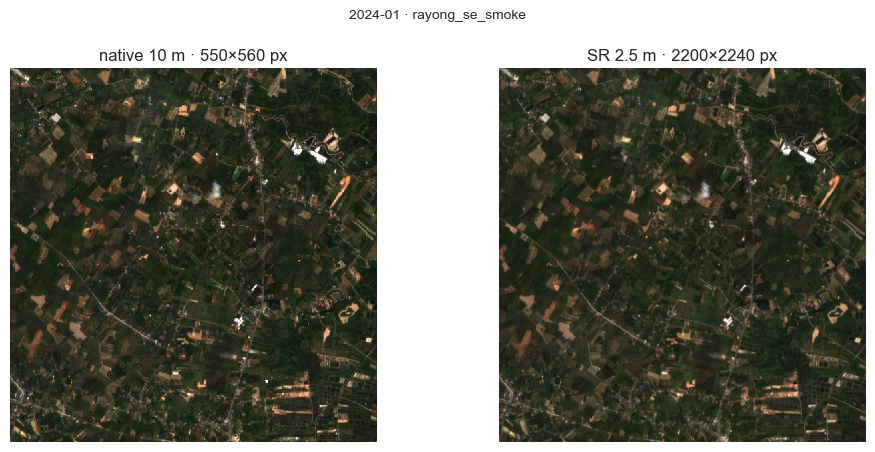

[2024-02] super-resolving (steps=25) …


2024-02 tiles:   0%|          | 0/36 [00:00<?, ?it/s]

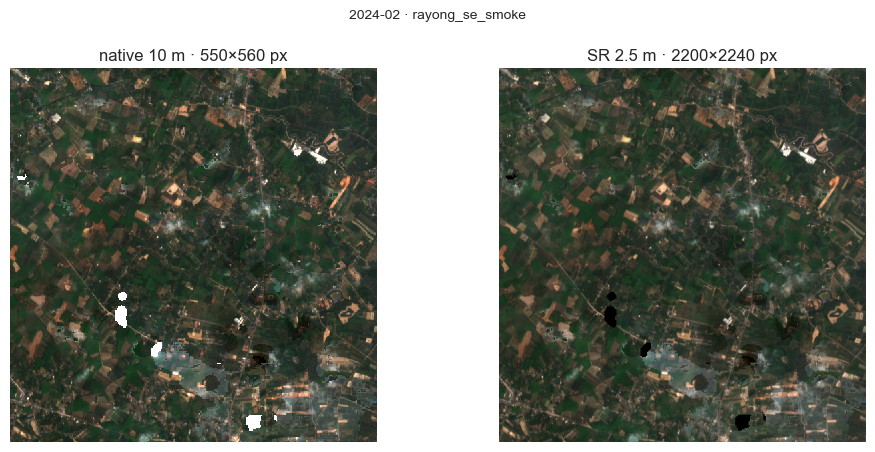

SR stack (2, 4, 2240, 2200) · res (2.5, -2.5)


In [9]:
@torch.no_grad()
def super_resolve_month(month_arr: xr.DataArray, tile: int = 128, overlap: int = 32, steps: int | None = None, desc: str = "tiles") -> xr.DataArray:
    """Tile-wise SR. Model expects (B, 4, 128, 128) and returns 4x upsampled.

    steps  : diffusion sampling count. Defaults to CFG.sr_steps (25 in smoke
             mode, 50 in full load). Pass 100 to match OpenSR's reference.
    desc   : label for the inner per-tile progress bar.
    """
    if steps is None:
        steps = CFG.sr_steps
    model = get_sr_model()
    rgb_nir = month_arr.isel(band_idx=slice(0, 4)).values.astype("float32") / 10000.0
    C, H, W = rgb_nir.shape
    out = np.zeros((C, H * CFG.sr_scale, W * CFG.sr_scale), dtype="float32")
    cnt = np.zeros_like(out[0])

    step = tile - overlap
    coords = [(y, x) for y in range(0, H, step) for x in range(0, W, step)]
    for (y, x) in tqdm(coords, desc=desc, leave=False, mininterval=1.0):
        patch = rgb_nir[:, y:y+tile, x:x+tile]
        ph, pw = patch.shape[1], patch.shape[2]
        if ph < 16 or pw < 16: continue
        if ph < tile or pw < tile:
            pad = np.zeros((C, tile, tile), dtype="float32")
            pad[:, :ph, :pw] = patch
            patch = pad
        t = torch.from_numpy(patch).unsqueeze(0).to(DEVICE)
        sr = model.forward(t, sampling_steps=steps).squeeze(0).cpu().numpy()
        sr = sr[:, : ph * CFG.sr_scale, : pw * CFG.sr_scale]
        ys, xs = y * CFG.sr_scale, x * CFG.sr_scale
        out[:, ys:ys+sr.shape[1], xs:xs+sr.shape[2]] += sr
        cnt[ys:ys+sr.shape[1], xs:xs+sr.shape[2]] += 1
    out /= np.maximum(cnt[None], 1)

    sr_da = xr.DataArray(out, dims=("band_idx", "y", "x"), coords={"band_idx": list(range(C))})
    sr_da = sr_da.rio.write_crs(month_arr.rio.crs)
    sr_da = sr_da.rio.write_transform(month_arr.rio.transform() * rasterio.Affine.scale(1.0 / CFG.sr_scale))
    return sr_da


SR_DIR = CFG.cache_root / "s2_sr" / CFG.aoi_name
SR_DIR.mkdir(parents=True, exist_ok=True)

# Toggle per-month preview. Set False on long runs you don't want to watch.
SHOW_PREVIEW = True


def _preview_pair(nat_arr: np.ndarray, sr_arr: np.ndarray, title: str):
    """Quick native-vs-SR figure for a single month. nat/sr are (4, H, W) reflectance."""
    rgb = lambda a: np.clip(a[[2, 1, 0]] * 3.0, 0, 1).transpose(1, 2, 0)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
    ax[0].imshow(rgb(nat_arr), interpolation="nearest")
    ax[0].set_title(f"native 10 m · {nat_arr.shape[2]}×{nat_arr.shape[1]} px")
    ax[0].axis("off")
    ax[1].imshow(rgb(sr_arr))
    ax[1].set_title(f"SR 2.5 m · {sr_arr.shape[2]}×{sr_arr.shape[1]} px")
    ax[1].axis("off")
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()


sr_stack = []
months = list(S2.time.values)
for t in tqdm(months, desc="SR · months"):
    label = pd.to_datetime(t).strftime("%Y-%m")
    cache_p = SR_DIR / f"sr_{pd.to_datetime(t).strftime('%Y%m')}.tif"
    if cache_p.exists():
        sr = rxr.open_rasterio(cache_p, masked=True).astype("float32")
    else:
        tqdm.write(f"[{label}] super-resolving (steps={CFG.sr_steps}) …")
        sr = super_resolve_month(S2.sel(time=t), desc=f"{label} tiles")
        sr.rio.to_raster(cache_p, compress="DEFLATE", tiled=True)
    sr_stack.append(sr.expand_dims(time=[t]))

    if SHOW_PREVIEW:
        _nat = S2.sel(time=t).isel(band_idx=slice(0, 4)).values.astype("float32") / 10000.0
        _srv = sr.values.astype("float32")
        if _srv.max() > 5:  # tolerate either 0-1 or 0-10000 cached scale
            _srv = _srv / 10000.0
        _preview_pair(_nat, _srv, f"{label} · {CFG.aoi_name}")

SR = xr.concat(sr_stack, dim="time")
print(f"SR stack {SR.shape} · res {SR.rio.resolution()}")


## 4 · Generative augmentation

Minority crop classes have <1 % of pixels. SMOTE-style duplication adds noise; we generate new patches instead.

- **4a** · LoRA fine-tune of the SR diffusion UNet per minority class. Guaranteed S2 radiometry, ~10 MB per class.
- **4b** · DiffusionSat (Khanna et al., 2024) class-conditional sampling. Off-the-shelf, no fine-tuning.


In [9]:
from peft import LoraConfig, get_peft_model
import torch.nn.functional as F


def _find_unet(model):
    """opensr-model exposes the UNet at different attribute paths between releases."""
    for path in ("unet", "model.diffusion_model", "model.unet", "model.model.diffusion_model"):
        obj = model
        try:
            for part in path.split("."): obj = getattr(obj, part)
            return obj, path
        except AttributeError:
            continue
    raise AttributeError("UNet not found inside SRLatentDiffusion — patch _find_unet().")


def build_lora_sr(class_code: str):
    base = get_sr_model()
    unet, path = _find_unet(base)
    lora = LoraConfig(r=8, lora_alpha=16, target_modules=["to_q","to_k","to_v","to_out.0"], lora_dropout=0.0, bias="none")
    wrapped = get_peft_model(unet, lora)
    parent = base
    parts = path.split(".")
    for part in parts[:-1]: parent = getattr(parent, part)
    setattr(parent, parts[-1], wrapped)
    print(f"LoRA params for {class_code}: {sum(p.numel() for p in wrapped.parameters() if p.requires_grad):,}")
    return base


def train_lora(class_code: str, patches: np.ndarray, epochs: int = 40, lr: float = 1e-4):
    """patches: (N, 4, 64, 64) reflectance crops of the target class."""
    model = build_lora_sr(class_code)
    opt = torch.optim.AdamW([p for p in model.unet.parameters() if p.requires_grad], lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.from_numpy(patches).float()),
        batch_size=8, shuffle=True, drop_last=True,
    )
    for ep in range(epochs):
        run = 0.0
        for (x,) in loader:
            x = x.to(DEVICE)
            t = torch.randint(0, model.scheduler.config.num_train_timesteps, (x.size(0),), device=DEVICE)
            noise = torch.randn_like(x)
            xt = model.scheduler.add_noise(x, noise, t)
            loss = F.mse_loss(model.unet(xt, t).sample, noise)
            opt.zero_grad(); loss.backward(); opt.step()
            run += loss.item()
        sched.step()
        if ep % 5 == 0: print(f"  ep {ep:3d}  loss {run/len(loader):.4f}")
    out = CFG.cache_root / "lora" / f"{class_code}.pt"
    out.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.unet.state_dict(), out)
    return out


In [ ]:
# DiffusionSat is optional. Its repo + transitive deps target old
# diffusers / huggingface_hub. Modern envs drift two APIs:
#   1. diffusers.models.cross_attention → diffusers.models.attention
#   2. huggingface_hub.cached_download   → huggingface_hub.hf_hub_download
# We register both shims BEFORE importing diffusionsat. If anything else
# still trips, the cell falls back to DSAT = None and §4b is skipped —
# the LoRA path in §4a already covers the GenAI stage.
import importlib

# --- shim 1: cached_download (deprecated, then removed in hf_hub >= 0.26) -----
try:
    import huggingface_hub as _hf
    if not hasattr(_hf, "cached_download") and hasattr(_hf, "hf_hub_download"):
        _hf.cached_download = _hf.hf_hub_download
except Exception as _e:
    print("note: could not patch huggingface_hub.cached_download →", _e)

# --- shim 2: diffusers.models.cross_attention → diffusers.models.attention ---
try:
    if "diffusers.models.cross_attention" not in sys.modules:
        _attn = importlib.import_module("diffusers.models.attention")
        sys.modules["diffusers.models.cross_attention"] = _attn
        for old, new in [("CrossAttention", "Attention"),
                          ("CrossAttnProcessor", "AttnProcessor")]:
            if hasattr(_attn, new) and not hasattr(_attn, old):
                setattr(_attn, old, getattr(_attn, new))
except Exception as _e:
    print("note: could not alias diffusers.models.cross_attention →", _e)

sys.path.insert(0, str(CFG.diffusionsat_repo))
DSAT = None
try:
    from diffusionsat import DiffusionSatPipeline
    DSAT = DiffusionSatPipeline.from_pretrained("samar-khanna/DiffusionSat", torch_dtype=torch.float16).to(DEVICE)
    print("DiffusionSat loaded")
except Exception as e:
    print("DiffusionSat unavailable — §4b will be skipped:", e)
    print("LoRA (§4a) already covers the GenAI stage; DiffusionSat is comparison-only.")
    print("If you really need DSAT, the only reliable fix is a pinned legacy env:")
    print("  pip install 'diffusers==0.18.2' 'huggingface_hub==0.16.4' 'transformers==4.30.2'")
    print("  (this may break opensr-model — keep a separate env for DSAT-only runs).")


def sample_diffusionsat(class_name: str, n: int = 8, lat: float = 12.75, lng: float = 101.6, ts: str = "2024-07-01"):
    if DSAT is None: raise RuntimeError("DiffusionSat pipeline not initialised")
    prompt = f"Sentinel-2 satellite patch of {class_name}, rural Thailand"
    return DSAT(
        prompt=[prompt] * n,
        metadata={"lat": [lat]*n, "lng": [lng]*n, "ts": [ts]*n},
        num_inference_steps=40, guidance_scale=7.5,
    ).images


## 5 · Native vs SR

Three views:

1. Full AOI side-by-side at native 10 m and super-resolved 2.5 m.
2. Zoomed-in crop so the per-pixel detail gain is obvious.
3. SR thumbnail strip across all months (cloud-mask + temporal coherence check).


In [ ]:
def to_rgb(arr: np.ndarray, gain: float = 3.0) -> np.ndarray:
    """Reflectance (4, H, W) → uint8 RGB (H, W, 3). Band order: B02 B03 B04 B08."""
    rgb = np.clip(arr[[2, 1, 0]] * gain, 0, 1)
    return (rgb.transpose(1, 2, 0) * 255).astype("uint8")


mid = S2.time.values[len(S2.time)//2]
native = S2.sel(time=mid).isel(band_idx=slice(0, 4)).values / 10000.0
sr_now = SR.sel(time=mid).values

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
ax[0].imshow(to_rgb(native)); ax[0].set_title(f"Native 10 m · {native.shape[2]}×{native.shape[1]} px"); ax[0].axis("off")
ax[1].imshow(to_rgb(sr_now)); ax[1].set_title(f"SR 2.5 m · {sr_now.shape[2]}×{sr_now.shape[1]} px"); ax[1].axis("off")
plt.suptitle(f"{CFG.aoi_name} · {pd.to_datetime(mid).strftime('%Y-%m')} · full AOI")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "native_vs_sr_full.png", dpi=160, bbox_inches="tight")
plt.show()


In [ ]:
# zoomed crop: take a 64×64 native window (= 256×256 SR), centred on AOI.
H10, W10 = native.shape[1:]
cy, cx = H10 // 2, W10 // 2
win = 32
nat_crop = native[:, cy-win:cy+win, cx-win:cx+win]
sr_crop  = sr_now[:, cy*CFG.sr_scale - win*CFG.sr_scale: cy*CFG.sr_scale + win*CFG.sr_scale,
                     cx*CFG.sr_scale - win*CFG.sr_scale: cx*CFG.sr_scale + win*CFG.sr_scale]

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
# nearest-neighbour resize the native crop to match SR pixel count, so the eye
# compares like-for-like instead of being fooled by the smaller native canvas.
ax[0].imshow(to_rgb(nat_crop), interpolation="nearest")
ax[0].set_title(f"Native 10 m · {nat_crop.shape[2]}×{nat_crop.shape[1]} px (nearest)")
ax[0].axis("off")
ax[1].imshow(to_rgb(sr_crop))
ax[1].set_title(f"SR 2.5 m · {sr_crop.shape[2]}×{sr_crop.shape[1]} px")
ax[1].axis("off")
plt.suptitle(f"{CFG.aoi_name} · {pd.to_datetime(mid).strftime('%Y-%m')} · centre crop")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "native_vs_sr_crop.png", dpi=160, bbox_inches="tight")
plt.show()


In [ ]:
# Monthly SR strip — quick eyeball check that the cloud mask + median worked.
n_t = len(SR.time)
cols = min(n_t, 6)
rows = math.ceil(n_t / cols)
fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.4 * rows))
axes = np.atleast_1d(axes).ravel()
for ax in axes: ax.axis("off")
for i, t in enumerate(SR.time.values):
    axes[i].imshow(to_rgb(SR.sel(time=t).values))
    axes[i].set_title(pd.to_datetime(t).strftime("%Y-%m"), fontsize=9)
plt.suptitle(f"SR monthly composites · {CFG.aoi_name}")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "sr_monthly_strip.png", dpi=160, bbox_inches="tight")
plt.show()


In [ ]:
# Reflectance histogram per band — sanity check that SR didn't drift the
# distribution. Native + SR should land in the same shape; an extreme tail
# shift means the SR model is leaking into out-of-distribution territory.
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
bands = ["B02", "B03", "B04", "B08"]
for i, ax in enumerate(axes):
    ax.hist(native[i].ravel(),  bins=60, alpha=0.55, label="native 10 m", color="#5B8B7C")
    ax.hist(sr_now[i].ravel(),  bins=60, alpha=0.55, label="SR 2.5 m",    color="#C96442")
    ax.set_title(bands[i]); ax.set_xlabel("reflectance")
axes[0].set_ylabel("pixels"); axes[0].legend(fontsize=8)
plt.suptitle(f"Band-wise reflectance histograms · {pd.to_datetime(mid).strftime('%Y-%m')}")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "sr_band_histograms.png", dpi=160, bbox_inches="tight")
plt.show()

# numeric summary
print(f"{'band':>5}  {'native μ':>10}  {'SR μ':>10}  {'native σ':>10}  {'SR σ':>10}")
for i, b in enumerate(bands):
    print(f"{b:>5}  {native[i].mean():>10.4f}  {sr_now[i].mean():>10.4f}  {native[i].std():>10.4f}  {sr_now[i].std():>10.4f}")


## 6 · Rasterise LDD landuse onto the SR grid

In [ ]:
from rasterio.features import rasterize

LU_SHP = next(CFG.ldd_landuse.glob("*.shp"))
print("LDD landuse:", LU_SHP.name)

lu = gpd.read_file(LU_SHP).to_crs(SR.rio.crs)
print("top classes:", lu["LU_CODE"].value_counts().head(8).to_dict())

code_to_int = {c: i+1 for i, c in enumerate(sorted(lu["LU_CODE"].dropna().unique()))}
int_to_code = {v: k for k, v in code_to_int.items()}
lu["lu_int"] = lu["LU_CODE"].map(code_to_int).fillna(0).astype("int32")

out_shape = SR.isel(time=0).shape[1:]
LABELS = rasterize(
    [(g, v) for g, v in zip(lu.geometry, lu["lu_int"]) if v > 0],
    out_shape=out_shape, transform=SR.rio.transform(), fill=0, dtype="int32",
)
print(f"labels {LABELS.shape} · non-zero {(LABELS>0).mean():.2%}")


In [ ]:
def extract_class_patches(class_code: str, n: int = 200, size: int = 64) -> np.ndarray:
    cls = code_to_int[class_code]
    yy, xx = np.where(LABELS == cls)
    if len(yy) < n: n = len(yy)
    idx = np.random.RandomState(CFG.seed).choice(len(yy), size=n, replace=False)
    H, W = LABELS.shape
    half = size // 2
    sr_mid = SR.isel(time=len(SR.time)//2).values
    out = []
    for y, x in zip(yy[idx], xx[idx]):
        if y-half < 0 or x-half < 0 or y+half > H or x+half > W: continue
        out.append(sr_mid[:, y-half:y+half, x-half:x+half] / 10000.0)
    return np.stack(out).astype("float32")


patches_by_class = {c: extract_class_patches(c) for c in CFG.minority_classes if c in code_to_int}
for c, p in patches_by_class.items(): print(f"  {c}: {p.shape}")


## 7 · Pixel feature table

Per-pixel = monthly band stats + vegetation indices + GLCM/LBP texture + `LU_CODE` label.


In [ ]:
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern


def build_pixel_table(stride: int = 8) -> pd.DataFrame:
    n_t = len(SR.time)
    H, W = LABELS.shape
    yy, xx = np.meshgrid(np.arange(0, H, stride), np.arange(0, W, stride), indexing="ij")
    yy, xx = yy.ravel(), xx.ravel()
    keep = LABELS[yy, xx] > 0
    yy, xx = yy[keep], xx[keep]
    print(f"sampled {len(yy):,} pixels (stride={stride})")

    spec = np.zeros((len(yy), n_t, 4), dtype="float32")
    for ti, t in enumerate(SR.time.values):
        spec[:, ti, :] = SR.sel(time=t).values[:, yy, xx].T / 10000.0

    stats = {}
    for b, name in enumerate(["B02","B03","B04","B08"]):
        stats[f"{name}_mean"] = spec[:,:,b].mean(axis=1)
        stats[f"{name}_std"]  = spec[:,:,b].std(axis=1)
        stats[f"{name}_p90"]  = np.percentile(spec[:,:,b], 90, axis=1)
        stats[f"{name}_min"]  = spec[:,:,b].min(axis=1)
        stats[f"{name}_max"]  = spec[:,:,b].max(axis=1)

    ndvi = (spec[:,:,3] - spec[:,:,2]) / (spec[:,:,3] + spec[:,:,2] + 1e-6)
    ndwi = (spec[:,:,1] - spec[:,:,3]) / (spec[:,:,1] + spec[:,:,3] + 1e-6)
    stats["NDVI_mean"] = ndvi.mean(axis=1); stats["NDVI_max"] = ndvi.max(axis=1); stats["NDVI_amp"] = ndvi.max(axis=1) - ndvi.min(axis=1)
    stats["NDWI_mean"] = ndwi.mean(axis=1)

    df = pd.DataFrame(stats)
    df["y"], df["x"], df["label"] = yy, xx, LABELS[yy, xx]
    return df


DF = build_pixel_table(stride=8)
DF.to_parquet(CFG.out_root / "pixel_table.parquet")
print(DF.shape, "→", CFG.out_root / "pixel_table.parquet")
DF.head()


### 7.1 · Balance

In [ ]:
from imblearn.over_sampling import RandomOverSampler

X_cols = [c for c in DF.columns if c not in ("y","x","label")]
X, y = DF[X_cols].values, DF["label"].values
print("raw counts:", dict(zip(*np.unique(y, return_counts=True))))

X_bal, y_bal = RandomOverSampler(sampling_strategy="not majority", random_state=CFG.seed).fit_resample(X, y)
print("balanced :", dict(zip(*np.unique(y_bal, return_counts=True))))


## 8 · Random Forest cascade

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

X_tr, X_va, y_tr, y_va = train_test_split(X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=CFG.seed)

rf = RandomForestClassifier(
    n_estimators=CFG.rf_n_estimators, max_depth=CFG.rf_max_depth,
    n_jobs=-1, random_state=CFG.seed, class_weight="balanced_subsample",
)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_va)
print(classification_report(y_va, y_pred, digits=3))


In [ ]:
imp = pd.Series(rf.feature_importances_, index=X_cols).sort_values(ascending=True)
plt.figure(figsize=(6, 8)); imp.plot(kind="barh")
plt.title("RF feature importance"); plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "rf_importance.png", dpi=160, bbox_inches="tight")
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_va, y_pred, normalize="true", cmap="rocket_r", values_format=".2f", ax=ax)
ax.set_title("RF · validation confusion (row-norm)")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "rf_confusion.png", dpi=160, bbox_inches="tight")
plt.show()


### 8.1 · Cascade — second RF on minority classes

In [ ]:
minor_ints = [code_to_int[c] for c in CFG.minority_classes if c in code_to_int]
mask = np.isin(y_bal, minor_ints)
print("minority pixels:", mask.sum())

rf_minor = RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=CFG.seed, class_weight="balanced_subsample")
if mask.sum() > 100: rf_minor.fit(X_bal[mask], y_bal[mask])


def cascade_predict(X, conf_thresh: float = 0.6):
    proba = rf.predict_proba(X)
    pred = rf.classes_[proba.argmax(axis=1)]
    conf = proba.max(axis=1)
    route = (conf < conf_thresh) | np.isin(pred, [c for c in rf.classes_ if c not in minor_ints])
    if mask.sum() > 100 and route.any():
        pred[route] = rf_minor.predict(X[route])
    return pred


y_pred_cas = cascade_predict(X_va)
print("Cascade:")
print(classification_report(y_va, y_pred_cas, digits=3))


In [ ]:
import joblib
joblib.dump(rf,       CFG.out_root / "rf_stage1.joblib")
joblib.dump(rf_minor, CFG.out_root / "rf_stage2_minor.joblib")
(CFG.out_root / "code_to_int.json").write_text(json.dumps({k: int(v) for k, v in code_to_int.items()}, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved →", CFG.out_root)


## 9 · Board feedback

Map outputs back to (member, stage) `done / total` rows in Supabase:

| Stage  | `done`                                                  | `total`                     |
| ------ | ------------------------------------------------------- | --------------------------- |
| Data   | cloud-free monthly composites fetched                   | months requested (≤12)      |
| SR     | SR GeoTIFFs persisted in `_cache/s2_sr/`                | same as Data                |
| GenAI  | LoRA adapters trained                                   | `len(CFG.minority_classes)` |
| Feat   | rows in `pixel_table.parquet` (`÷1000`)                 | target row budget           |
| RF     | `1` per model dumped (stage-1 + cascade)                | `2`                         |

Edit numbers in the tracker UI, or POST to the Supabase REST endpoint.


## 10 · Export `public/class-stats.json`

Standalone alternative: `python notebooks/export_class_stats.py` (no need to run the heavy cells above).


In [ ]:
import json, math
from datetime import datetime, timezone

RAYONG_CENTER = {"lng": 101.4291, "lat": 12.8539}

try:
    import mgrs as _mgrs_mod
    _mgrs = _mgrs_mod.MGRS()
except Exception:
    _mgrs = None
    print("note: pip install mgrs to add the per-S2-tile breakdown")

lu_m  = lu.to_crs(32647).copy()
lu_ll = lu.to_crs(4326).copy()
lu_ll["area_km2"] = (lu_m.area / 1e6).values
_cen = lu_m.geometry.centroid.to_crs(4326)
lu_ll["_cen_lng"], lu_ll["_cen_lat"] = _cen.x.values, _cen.y.values


def _quad(lng, lat):
    return ("N" if lat >= RAYONG_CENTER["lat"] else "S") + ("E" if lng >= RAYONG_CENTER["lng"] else "W")


def _tile(lng, lat):
    if _mgrs is None: return None
    try:
        s = _mgrs.toMGRS(lat, lng, MGRSPrecision=0)
        return s[:5] if isinstance(s, str) and len(s) >= 5 else None
    except Exception: return None


lu_ll["_quadrant"] = [_quad(x, y) for x, y in zip(lu_ll._cen_lng, lu_ll._cen_lat)]
lu_ll["_s2_tile"]  = [_tile(x, y) for x, y in zip(lu_ll._cen_lng, lu_ll._cen_lat)]

CLASS_COL = "LUL2_CODE" if "LUL2_CODE" in lu_ll.columns else "LU_CODE"
lu_ll[CLASS_COL] = lu_ll[CLASS_COL].astype(str).fillna("__unk__")
lu_ll = lu_ll[~lu_ll[CLASS_COL].str.contains("/")].copy()  # drop mixed-class polygons

total_by_class = lu_ll.groupby(CLASS_COL)["area_km2"].sum().sort_values(ascending=False)
ordered = [str(c) for c in total_by_class.index]
lu_ll["_class"] = lu_ll[CLASS_COL]
minority_ids = list(CFG.minority_classes)

PALETTE = ["#3F7D58","#3F6E97","#C96442","#B68A2E","#7B5BA6","#9B5C7A",
           "#4F7A95","#7C7A52","#A85C9D","#5F8A6E","#8B6F47","#D4A748",
           "#5B8B7C","#A67B5B","#6B7280","#9B7CB6","#C68A6C","#7AA66D"]
MINORITY_COLOR = "#B14B3D"

class_defs = []
for i, cid in enumerate(ordered):
    is_min = cid in minority_ids
    class_defs.append({"id": cid, "label": cid, "color": MINORITY_COLOR if is_min else PALETTE[i % len(PALETTE)], "minority": is_min})


def _block(df):
    grp = df.groupby("_class")["area_km2"].sum().reindex(ordered, fill_value=0.0)
    total = float(grp.sum())
    rows = [{"id": cid, "area_km2": float(grp.loc[cid]), "share": float(grp.loc[cid] / total) if total else 0.0} for cid in ordered]
    rows.sort(key=lambda c: -c["share"])
    return {"area_km2_total": total, "classes": rows}


def _metrics(block):
    sh = [c["share"] for c in block["classes"] if c["share"] > 0]
    shannon = -sum(s * math.log2(s) for s in sh)
    xs = sorted(sh); n = len(xs)
    gini = (2 * sum((i+1) * s for i, s in enumerate(xs)) / (n * sum(xs))) - (n + 1) / n if xs else 0.0
    return {"shannon": round(shannon, 4), "gini": round(gini, 4),
            "max_min_ratio": round(max(xs)/min(xs), 3) if xs else 0.0}


areas = [{"key": "overall", "label": "All Rayong", "kind": "overall", **_block(lu_ll), "metrics": _metrics(_block(lu_ll))}]
for q, lbl in [("NW","Northwest"),("NE","Northeast"),("SW","Southwest"),("SE","Southeast")]:
    b = _block(lu_ll[lu_ll["_quadrant"] == q])
    areas.append({"key": q, "label": lbl, "kind": "quadrant", **b, "metrics": _metrics(b)})

if _mgrs is not None:
    for tile, sub in sorted(lu_ll.groupby("_s2_tile")):
        if not tile: continue
        b = _block(sub)
        if b["area_km2_total"] < 1.0: continue
        areas.append({"key": str(tile), "label": str(tile), "kind": "s2_tile", **b, "metrics": _metrics(b)})

payload = {
    "version": 1,
    "generated_at": datetime.now(timezone.utc).isoformat().replace("+00:00", "Z"),
    "source": f"LDD landuse · {LU_SHP.name}",
    "classes": class_defs, "areas": areas,
}

for root in (CFG.repo_root, Path.cwd().parent, Path.cwd()):
    if (root / "package.json").exists():
        out_path = root / "public" / "class-stats.json"
        break
else:
    out_path = CFG.repo_root / "public" / "class-stats.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"wrote {out_path} · {len(class_defs)} classes · {len(areas)} areas")
